In [2]:
# --- Setup: import libraries and load data ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Load the dataset (ensure the CSV file is in the working directory or uploaded in Colab)
df = pd.read_csv("Customer Churn new.csv")
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (10000, 11)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


In [3]:
# Check data info and summary statistics
display(df.info())
display(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


None

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,149388.247500,0.000000


In [4]:
# --- Data Cleaning and Encoding ---
# Drop identifier columns (they are not useful for prediction)
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical text columns to numeric
le = LabelEncoder()
df_clean['Geography'] = le.fit_transform(df_clean['Geography'])
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# Separate features and target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Show the updated dataframe structure
print(f"Cleaned data shape: {df_clean.shape}")
display(df_clean.head())


Cleaned data shape: (10000, 8)


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,844,0,1,18,2,160980.03,145936.28,0
1,656,0,1,18,10,151762.74,127014.32,0
2,570,0,0,18,4,82767.42,71811.90,0
3,716,1,0,18,3,128743.80,197322.13,0
4,727,0,1,18,4,133550.67,46941.41,0


/tmp/ipykernel_5871/2359953341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df_clean, palette='viridis')


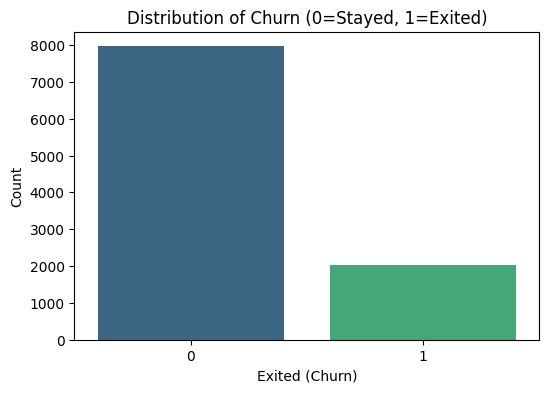

Churn distribution (0 = stay, 1 = exit):
Exited
0    7963
1    2037
Name: count, dtype: int64


In [5]:
# --- EDA Plot A: Class Distribution (Churn vs Non-Churn) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df_clean, palette='viridis')
plt.title('Distribution of Churn (0=Stayed, 1=Exited)')
plt.xlabel('Exited (Churn)')
plt.ylabel('Count')
plt.show()

print("Churn distribution (0 = stay, 1 = exit):")
print(df_clean['Exited'].value_counts())


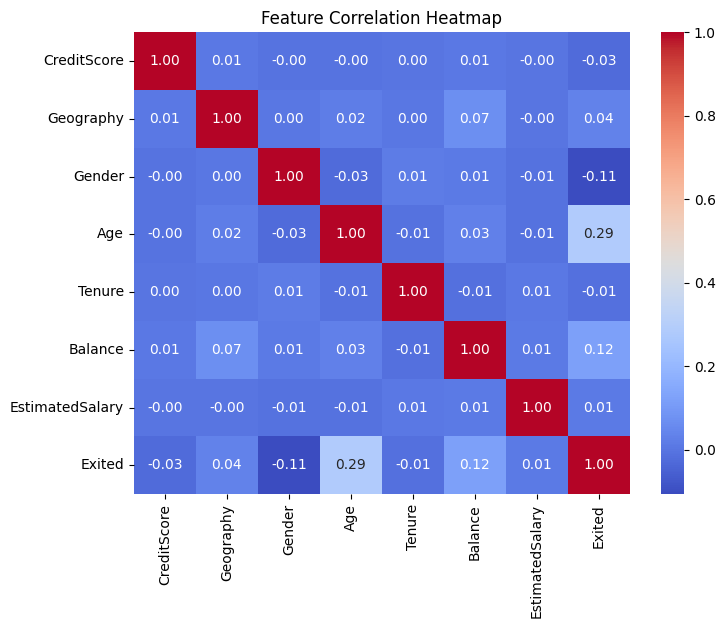

In [6]:
# --- EDA Plot B: Feature Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


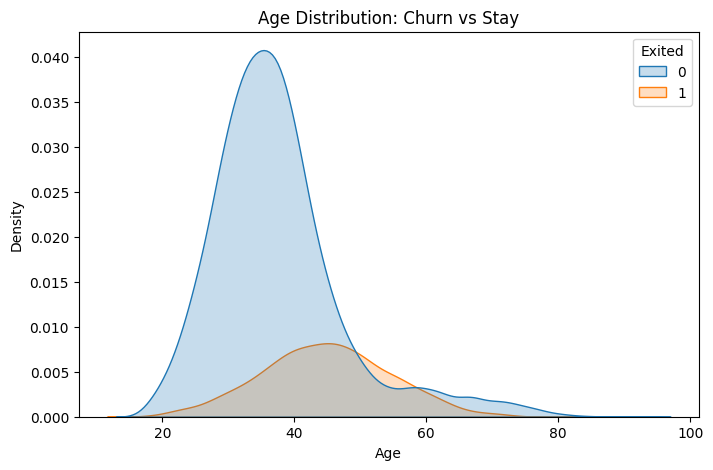

In [7]:
# --- EDA Plot C: Age Distribution by Churn ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_clean, x='Age', hue='Exited', fill=True)
plt.title('Age Distribution: Churn vs Stay')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()


In [8]:
# --- Prepare data for training ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

# Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Train Logistic Regression ---
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("Model training completed.")


Training set size: 8000 samples
Test set size:     2000 samples
Model training completed.


In [9]:
# --- Predictions and Basic Metrics ---
y_pred = model.predict(X_test_scaled)
accuracy = np.round(model.score(X_test_scaled, y_test), 3)
print(f"Accuracy on test set: {accuracy*100:.1f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy on test set: 78.6%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      1593
           1       0.38      0.08      0.13       407

    accuracy                           0.79      2000
   macro avg       0.59      0.52      0.51      2000
weighted avg       0.72      0.79      0.73      2000



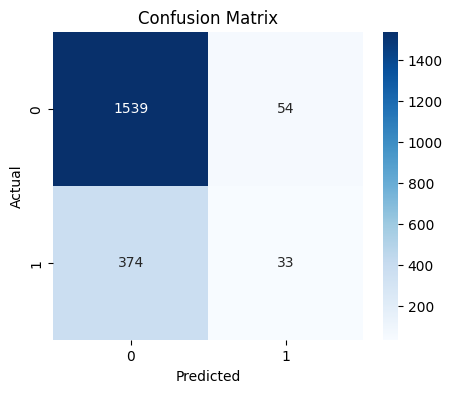

In [10]:
# --- Plot D: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


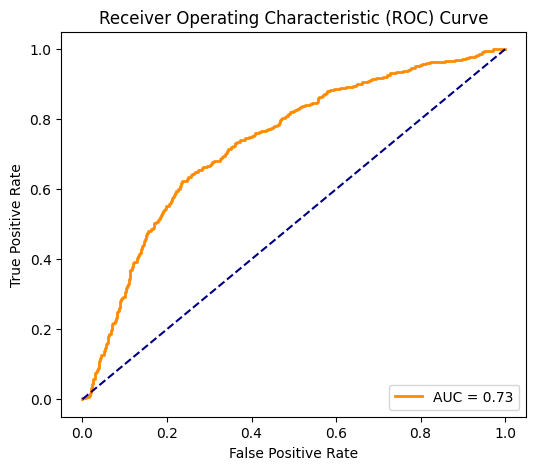

ROC AUC score: 0.734


In [11]:
# --- Plot E: ROC Curve and AUC ---
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()
print(f"ROC AUC score: {roc_auc:.3f}")


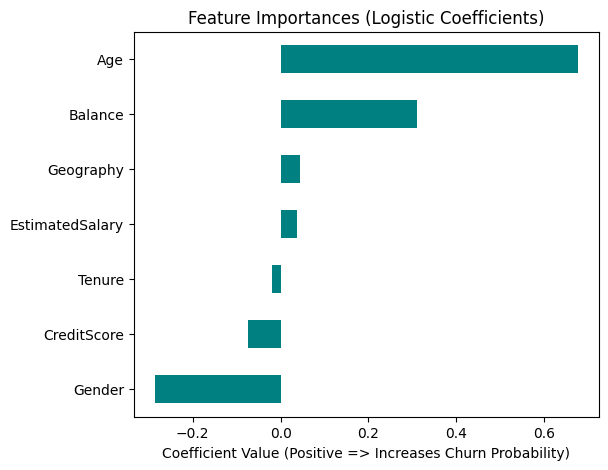

In [12]:
# --- Plot F: Feature Importance (Model Coefficients) ---
coefficients = model.coef_[0]
feature_names = X.columns
feat_imp = pd.Series(coefficients, index=feature_names).sort_values()

plt.figure(figsize=(6, 5))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importances (Logistic Coefficients)')
plt.xlabel('Coefficient Value (Positive => Increases Churn Probability)')
plt.show()
